<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/17_regularized-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 17: Regularized regression

This homework assignment is designed to give you an intuition as an interesting property of regularization in the context of ultra-high dimensional statistical problems.

You won't need to load in any data for this homework.

---
## 1. Simulating & visualizing data (2 points)

We are going to be looking at what happens in the context where $p>n$. In order to have total control over our data, we will use simulations for this homework. First, we will need to load the `glmnet`, `tidyverse`, and `ggplot2` libraries for this assignment.


In [2]:
install.packages('glmnet')
install.packages('tidyverse')
install.packages('ggplot2')

library(glmnet)
library(tidyverse)
library(ggplot2)

also installing the dependencies ‘iterators’, ‘foreach’, ‘shape’





The downloaded binary packages are in
	/var/folders/98/fcbf3bz156j770hhtccd780w0000gq/T//Rtmppq0Mav/downloaded_packages

The downloaded binary packages are in
	/var/folders/98/fcbf3bz156j770hhtccd780w0000gq/T//Rtmppq0Mav/downloaded_packages

The downloaded binary packages are in
	/var/folders/98/fcbf3bz156j770hhtccd780w0000gq/T//Rtmppq0Mav/downloaded_packages


Loading required package: Matrix

Loaded glmnet 4.1-10

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


We are going to generate a data set with complex structure and try to recover it using polynomial models. For simplicity sake, use the following code to produce a response variable, $y$ that has complex structure.

*Hint: Look up what a cosine function looks like if you need a reminder.*

In [3]:
# Generate data
set.seed(121)
sigma_noise = .5
x=seq(-9,9,by=.18)
n=length(x)
y = 0.1*x + cos(x) + cos(x/20)+rnorm(n,sd=sigma_noise)

(a) Break the data into a training set (n=50) and test set (n=51) using the `sample` function to randomly select subsets of x and y.  Make a separate data frame for the training and test data.

(**Note**: *Do not* just take the first 50 observations to be the training set and last 51 observations to be the test set.)

In [8]:
set.seed(121) 
train_idx = sample(1:n, 50)
test_idx = (-train_idx) 

train_data = data.frame(x = x[train_idx], y = y[train_idx])
test_data = data.frame(x = x[-train_idx], y = y[-train_idx])

(b) Plot the training data ($x$ \& $y$). Describe the relationship that you see in the training data.

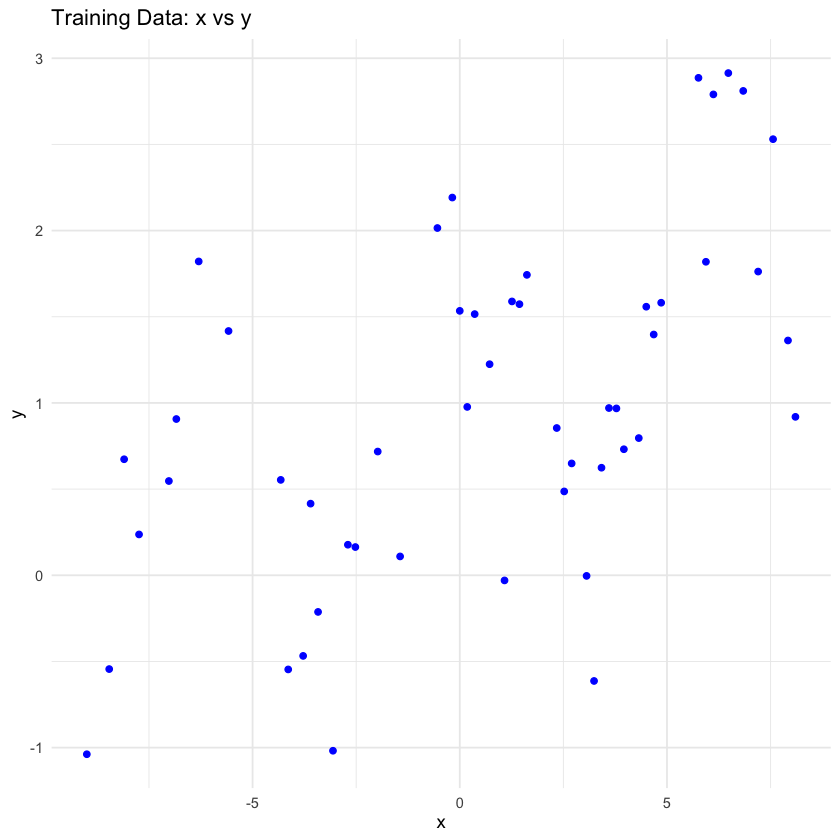

In [9]:
ggplot(train_data, aes(x = x, y = y)) +
  geom_point(color = "blue") +
  labs(title = "Training Data: x vs y",
       x = "x",
       y = "y") +
  theme_minimal()

How would you describe the relationship between $x$ and $y$ based on this plot?

> The result here is basically non-linear with an overall slightly positive trend. As x increases, y generally increases. However, this relationship is not simply a straight line. There is a clear wave-like/oscillating pattern superimposed on the upward trend, which makes sense given the data-generrating process involved cosine terms.
>
> More specifically, we can see that at the far left when x is around -8 to -7, y value dip low around -1, then rise to peaks near x = -6, where y is approximately 1.8, then dip again around x = -3 to -2, rise near x = 0, then generally clib higher on the right side with peaks around x = 6-7.
>
> There is also noticeable scatters and noises around the pattern. So in general, the data exhibits a non-linear, oscillating relationship with a slight positive trend.

---
## 2. Bias-variance tradeoff: polynomial regression (4 points)

Recall that in polynomial regression we increase model complexity by expanding $x$ out to the power $k$ (which we call degree).

$$
Y = \hat{\beta}_0 + \sum_{j=1}^K \hat{\beta}_j X^j
\;=\; \operatorname{poly}(X, K)
$$

(a) Fit a 2nd degree polynomial regression model to the training data. Plot the results.


*Hint: Use the* `help` *function to see how to use the* `stat_smooth()` *and* `poly()` *functions.*

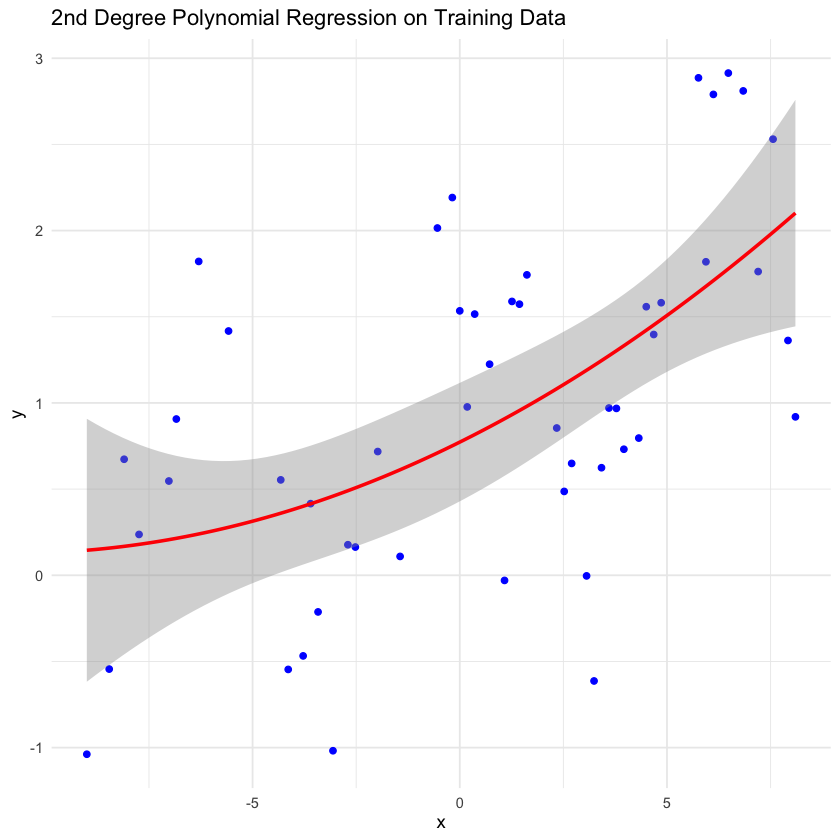

In [10]:
ggplot(train_data, aes(x = x, y = y)) +
  geom_point(color = "blue") +
  stat_smooth(method = "lm", formula = y ~ poly(x, 2), se = TRUE, color = "red") +
  labs(title = "2nd Degree Polynomial Regression on Training Data",
       x = "x",
       y = "y") +
  theme_minimal()

How well does this 2nd degree polynomial model qualitatively fit the data? Could it do better?

> The 2nd degree polynomial model does not fit the data very well. We can see that the quadratic curve captures the general positive trend in the data, but it misses the oscillating wave-like pattern that is clearly visible in the scatter of points. Also, many data points fall well outside of the confidence band, especially when x is around -6, -2, 0, and around 7-8.
>
> So the model definitely could be better. The underlying data has complex, oscillating structure from the cosine terms that a simple parabola just cannot capture. So a higher degree polynomial would have more flexibility to fit the peaks and valleys in the data.

(b) Fit a 12th degree polynomial to the data. Does this do qualitatively better or worse than the 2nd degree model?

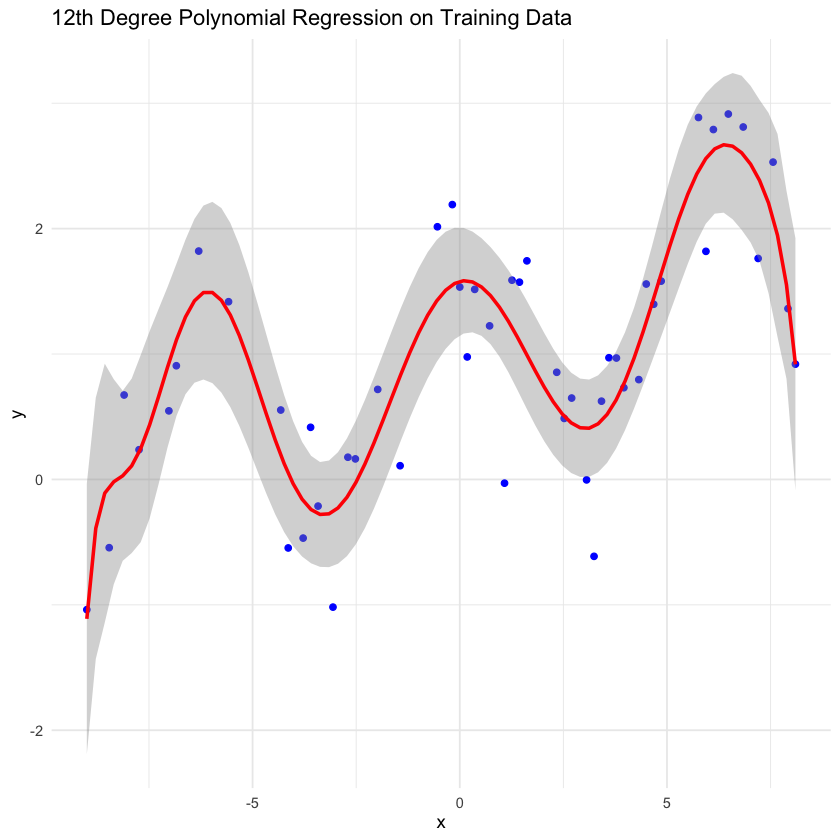

In [11]:
ggplot(train_data, aes(x = x, y = y)) +
  geom_point(color = "blue") +
  stat_smooth(method = "lm", formula = y ~ poly(x, 12), se = TRUE, color = "red") +
  labs(title = "12th Degree Polynomial Regression on Training Data",
       x = "x",
       y = "y") +
  theme_minimal()

> I think the 12th degree polynomial does qualitatively better than the 2nd degree model. First, it captures the oscillating pattern in the data much more effectively. We can see the curving rising and falling through the peaks and valleys. Also, more data points fall within or near the confidence interval band compared to the 2nd degree fit.

(c) Modify the loop below to estimate the bias-variance tradeoff as model complexity (i.e., degree of the polynomial model, $k$) increases from 2 to 50. Use the training data to fit the model and test data to evaluate its predictive accuracy.

Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.


(**Note**: We are using median accuracies here because there are often 1 or 2 outlier values in the higher degree polynomial models that can throw off the accuracy estimates).

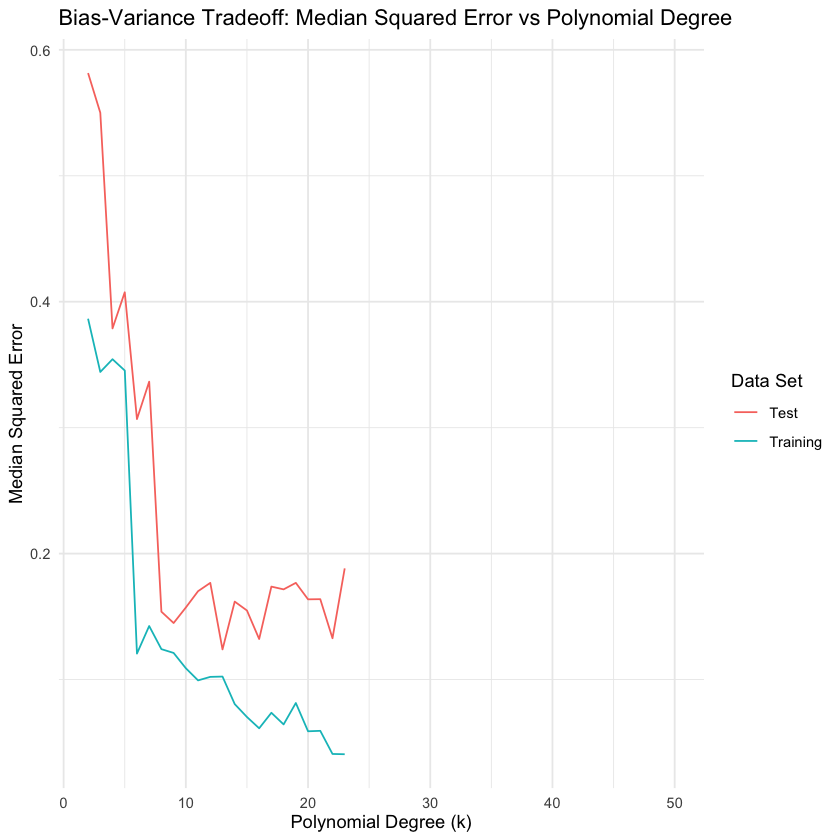

In [14]:
# Now do the variance-bias trade off analysis using regular regression
degree = seq(2,50)

# Need to setup your output vectors
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    tryCatch({
        poly_model = lm(y ~ poly(x, k), data = train_data)
        train_pred = predict(poly_model, train_data)
        train_rss[k-1] = median((train_data$y - train_pred)^2)
        test_pred = predict(poly_model, test_data)
        test_rss[k-1] = median((test_data$y - test_pred)^2)
    }, error = function(e) {
        train_rss[k-1] <<- NA
        test_rss[k-1] <<- NA
    })
}

# Plot your results here
results = data.frame(degree = degree,
                     train = train_rss,
                     test = test_rss)

ggplot(results, aes(x = degree)) +
  geom_line(aes(y = train, color = "Training"), na.rm = TRUE) +
  geom_line(aes(y = test, color = "Test"), na.rm = TRUE) +
  labs(title = "Bias-Variance Tradeoff: Median Squared Error vs Polynomial Degree",
       x = "Polynomial Degree (k)",
       y = "Median Squared Error",
       color = "Data Set") +
  theme_minimal()

What do you see as $k$ increase?

> I see the training error line consistently decreases as k increases. It is in general very low, meaning the model is fitting the model very well. Also, the test error line deps sharply at around k = 2 and when k increasing further to k = 8-10,. After that, it levels off and fluctuates rather than continuing to decrease. It doesn;t dramatically spike upward also, but it stays higher than the training error and show a light more variation/instability.

(d) Now copy the code above and let's see what happens when we go beyond $p=n$ (remember, in this case $k=p$). Test polynomial models up to $k=150$. Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.

Use the `geom_vline()` function in `ggplot` to draw a vertical line where $k=n$ (here $n$ is the number of observations in the training set). This will make it clear where we cross the threshold for finding *unique* solutions in our data.



Warning message in predict.lm(poly_model, train_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly_model, test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly_model, train_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly_model, test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly_model, train_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly_model, test_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly_model, train_data):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(poly_model, test_data):
“prediction from r

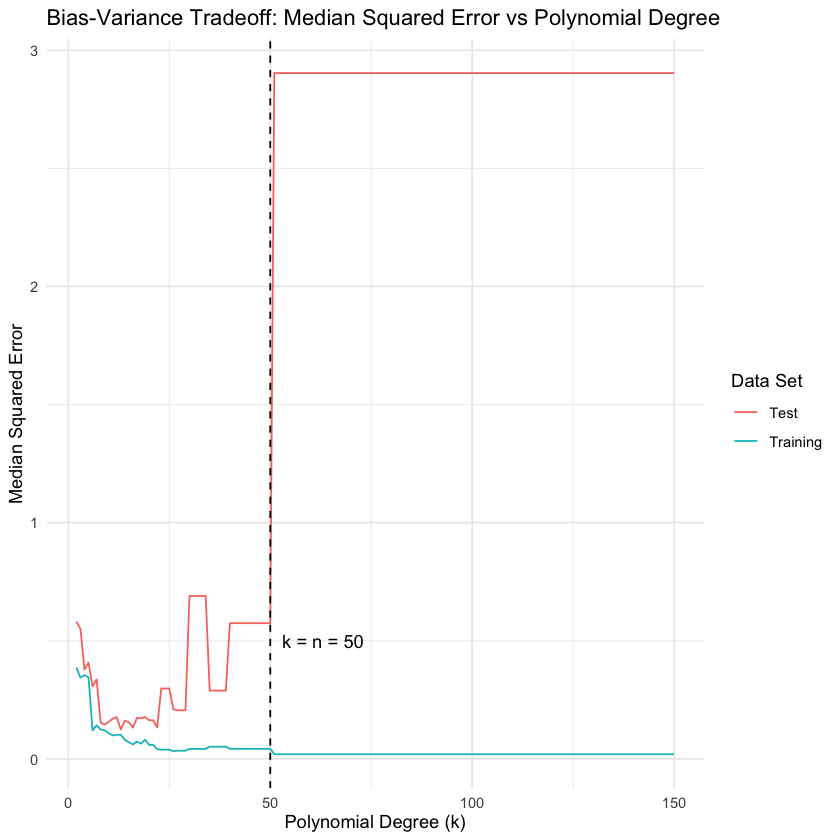

In [16]:
degree = seq(2, 150)

train_rss = matrix(data=NA, nrow=length(degree), ncol=1)
test_rss = matrix(data=NA, nrow=length(degree), ncol=1)

for (k in degree) {
    tryCatch({
        poly_model = lm(y ~ poly(x, k, raw = TRUE), data = train_data)
        
        train_pred = predict(poly_model, train_data)
        train_rss[k-1] = median((train_data$y - train_pred)^2)
        
        test_pred = predict(poly_model, test_data)
        test_rss[k-1] = median((test_data$y - test_pred)^2)
    }, error = function(e) {
        train_rss[k-1] <<- NA
        test_rss[k-1] <<- NA
    })
}

results = data.frame(degree = degree,
                     train = train_rss,
                     test = test_rss)

n_train = nrow(train_data)

ggplot(results, aes(x = degree)) +
  geom_line(aes(y = train, color = "Training"), na.rm = TRUE) +
  geom_line(aes(y = test, color = "Test"), na.rm = TRUE) +
  geom_vline(xintercept = n_train, linetype = "dashed", color = "black") +
  labs(title = "Bias-Variance Tradeoff: Median Squared Error vs Polynomial Degree",
       x = "Polynomial Degree (k)",
       y = "Median Squared Error",
       color = "Data Set") +
  annotate("text", x = n_train + 3, y = 0.5, label = paste("k = n =", n_train), hjust = 0) +
  theme_minimal()

What do you see as $k$ gets larger than $n$?

> The training error line drops to essentially zeto once k exceeds n = 50 and stays flat at zero. This may be becasue when p > n, the model has more parameters than data points, so it can perfectly interpolate every training observation.
>
> The test error line, right around k = n = 50, it spikes dramatically / vertically up on the y axis. After this spike, the test error never drop back and stabilized at a constant level. This could mean that the model then generates very poorly to unseen data from here.

---
## 3. Applying regularization to the model fits (2 points)

Repeat the previous bias-variance tradeoff test, going up to $k=150$, but now use ridge regression with a sparsity parameter of $\lambda=0.00005$. Plot your results the same way as last time.

Warning message:
“from glmnet C++ code (error code -1); Convergence for 1th lambda value not reached after maxit=100000 iterations; solutions for larger lambdas returned”
Warning message in getcoef(fit, nvars, nx, vnames):
“an empty model has been returned; probably a convergence issue”
Warning message:
“from glmnet C++ code (error code -1); Convergence for 1th lambda value not reached after maxit=100000 iterations; solutions for larger lambdas returned”
Warning message in getcoef(fit, nvars, nx, vnames):
“an empty model has been returned; probably a convergence issue”
Warning message:
“from glmnet C++ code (error code -1); Convergence for 1th lambda value not reached after maxit=100000 iterations; solutions for larger lambdas returned”
Warning message in getcoef(fit, nvars, nx, vnames):
“an empty model has been returned; probably a convergence issue”
Warning message:
“from glmnet C++ code (error code -1); Convergence for 1th lambda value not reached after maxit=100000 iterations; solu

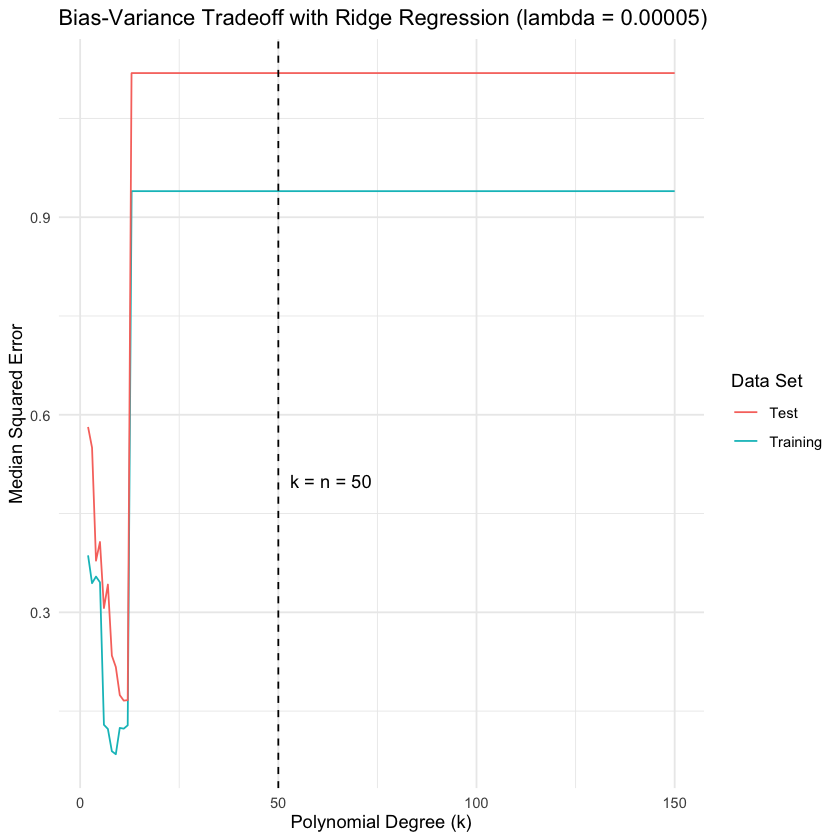

In [17]:
# Now do the variance-bias trade off analysis using ridge regression
lambda=0.00005
degree = seq(2,150)

rm(train_rss, test_rss)
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    tryCatch({
        train_x = poly(train_data$x, k, raw = TRUE)
        test_x = poly(test_data$x, k, raw = TRUE)
        
        ridge_model = glmnet(train_x, train_data$y, alpha = 0, lambda = lambda, thresh = 1e-12)
        
        train_pred = predict(ridge_model, newx = train_x, s = lambda)
        train_rss[k-1] = median((train_data$y - train_pred)^2)
        
        test_pred = predict(ridge_model, newx = test_x, s = lambda)
        test_rss[k-1] = median((test_data$y - test_pred)^2)
    }, error = function(e) {
        train_rss[k-1] <<- NA
        test_rss[k-1] <<- NA
    })
}


# Plot your results here
results = data.frame(degree = degree,
                     train = train_rss,
                     test = test_rss)

n_train = nrow(train_data)

ggplot(results, aes(x = degree)) +
  geom_line(aes(y = train, color = "Training"), na.rm = TRUE) +
  geom_line(aes(y = test, color = "Test"), na.rm = TRUE) +
  geom_vline(xintercept = n_train, linetype = "dashed", color = "black") +
  labs(title = "Bias-Variance Tradeoff with Ridge Regression (lambda = 0.00005)",
       x = "Polynomial Degree (k)",
       y = "Median Squared Error",
       color = "Data Set") +
  annotate("text", x = n_train + 3, y = 0.5, label = paste("k = n =", n_train), hjust = 0) +
  theme_minimal()

What happens now when $k$ gets larger than $n$?

> Unlike the previous results, the training line did not catastrophically break down when k exceeds n. Both training and test error lines had a large spike before k exceeds n, with testing line being higher than the training line. Then, they stablize after this spike and remain constant even until k rquals and exceeds n. Moreover, both lines fall back a little before the spike. Thus, both the training and ther testing error lines remain stable as a constant after k gets larger than n.

---
## 4. Reflection (2 points)

The simulations above should have shown that, when applying a regularization (i.e., a sparsity constraint), the behavior of the bias-variance tradeoff changes. Explain why this happens.

> Without regularization, when p > n, ordinary least squares has infinitely many solutions that could perfectly fit the training data. However, these solutions typically can involce very large and very widly vatied coefficients that fit the noise pretty well, So this can lead to terrible test perfoemance. Regularization adds a constraint that penalizes large coefficient values, which can efectively shrink them towards zero. It can slightly increase bias, but largely reduces variance since the coefficients are now more stable and less sensitive to noise in the trainig data. The net effevt is that when the model generalizes much better to unseen data, and the test error is not as big as when k is better than n. So the penalty is essencially trading a snall amount of training accuracy for brtter stability and generalization in test. 

---
## Bonus (1 extra credit point)
Recall that the $p=n$ threshold defines the limit for finding a *unique* solution to $Y=F(X)$ (i.e., there is only one combination of regression coefficients that is *best* at explaining variance in $Y$). With this in mind, what is regularization doing that works around this upper limit?

> When p>n, there are infinitely many solutions that can perfectly fit the training data, and OLS would have no better way for choosing among them since it picks one arbitarily, which can overfir badly, So the regulation works around this limit by adding anadditional constraint that minimizing the size of coeficients that effectively narrows down the infinite solution space to a single and better defined solution. So among all possible coefficient combinations that fit the data, the penalty selects the one with the smallest coefficient magnitudes.

**DUE:** 5pm EST, April 7, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*